# VOTING CLASSIFIER

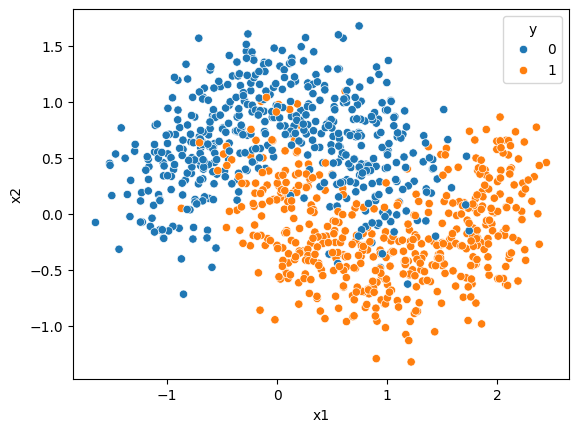

DecisionTreeClassifier: 91.5 100.0
SVC: 93.0 91.0
GaussianNB: 84.5 84.875
vc score  92.0 93.25


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns

x,y = make_moons(n_samples=1000, noise=0.3)

df = {'x1':x[:,0], 'x2':x[:,1], 'y':y}
ds = pd.DataFrame(df)
ds.head()

sns.scatterplot(x='x1', y= 'x2', data=df, hue='y')
plt.show()

x = ds.iloc[:,:-1]
y = ds['y']

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42, test_size=0.2)

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
print("DecisionTreeClassifier:", dt.score(x_test, y_test) * 100, dt.score(x_train, y_train) * 100)

svc =  SVC()
svc.fit(x_train,y_train)
print("SVC:", svc.score(x_test, y_test) * 100, svc.score(x_train, y_train) * 100)

gnb = GaussianNB()
gnb.fit(x_train,y_train)
print("GaussianNB:", gnb.score(x_test, y_test) * 100, gnb.score(x_train, y_train) * 100)

from sklearn.ensemble import VotingClassifier

li = [('dt1', dt), ('svc1', svc), ('gnb1', gnb)]

vc = VotingClassifier(li ,weights=[2,3,4])
vc.fit(x_train,y_train)
print('vc score ', vc.score(x_test,y_test)*100 , vc.score(x_train,y_train)*100)

 BAGGING CLASSIFIER and RANDOM FOREST CLASSIFIER 

In [3]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier


bg = BaggingClassifier(estimator=svc, n_estimators=100)
bg.fit(x_train,y_train)
print( bg.score(x_test,y_test)*100 , bg.score(x_train,y_train)*100)


rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train,y_train)
print(rf.score(x_test,y_test)*100 , rf.score(x_train,y_train)*100)

92.5 90.875
90.5 100.0


# VOTING REGRESSOR

LR SCORE  76.04591406745112 71.29693642568355
SVR SCORE  85.72371014172494 82.48090594447507
DT SCORE  76.19047619047619 97.39583333333334
VR score  87.22341245302681 91.40126540762058


<Axes: xlabel='age', ylabel='sal'>

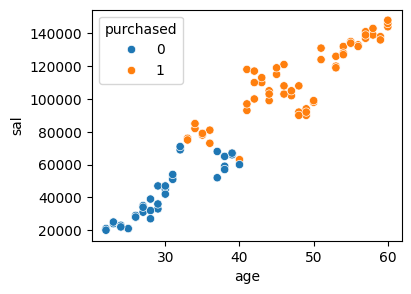

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor


ds = pd.read_csv('subs.csv')

x = ds.iloc[:,:-1]
y = ds.iloc[:,-1]

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42, test_size=0.2)

lr =  LinearRegression()
lr.fit(x_train,y_train)
print('LR SCORE ',lr.score(x_test,y_test)*100 , lr.score(x_train,y_train)*100)

svr = SVR()
svr.fit(x_train,y_train)
print('SVR SCORE ',svr.score(x_test,y_test)*100 , svr.score(x_train,y_train)*100)

dt = DecisionTreeRegressor()
dt.fit(x_train,y_train) 
print('DT SCORE ',dt.score(x_test,y_test)*100 , dt.score(x_train,y_train)*100)


li2 = [('dt', dt), ('svr', svr), ('lr', lr)]

vr = VotingRegressor(li2, weights=[11,9,7])
vr.fit(x_train,y_train)
print('VR score ', vr.score(x_test,y_test)*100 , vr.score(x_train,y_train)*100)


plt.figure(figsize=(4,3))
sns.scatterplot(x=ds.iloc[:,0], y=ds.iloc[:,1], data=ds, hue=ds.iloc[:,-1])

BAGGING META ESTIMATOR


In [5]:
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor

bgr = BaggingRegressor(estimator=dt, n_estimators=100,random_state=42)
bgr.fit(x_train,y_train)
print('BGR score ', bgr.score(x_test,y_test)*100 , bgr.score(x_train,y_train)*100)

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(x_train,y_train)
print('RFR score ', rfr.score(x_test,y_test)*100 , rfr.score(x_train,y_train)*100)


BGR score  90.776917989418 96.1231859085648
RFR score  91.07056878306878 96.11982942708333
